# Step 3 – Momentum Signal Construction

Here we build the trailing relative-strength indicator used to rank equities each month.  
The signal captures medium-term price persistence while deliberately skipping the most recent period to avoid short-horizon mean reversion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

## 1. Strategy Parameters
The table below summarises the tuneable knobs of the momentum framework:

| Param | Meaning | Default |
|-------|---------|--------|
| **L (lookback)** | Trailing window in months for cumulative return | 12 |
| **S (skip)** | Recent months excluded to dodge reversal noise | 1 |
| **H (hold)** | Holding duration per rebalance cohort | 3 |
| **Q (quantile)** | Fraction of universe labelled as top / bottom performers | 20% |

This is the standard **12-minus-1 momentum** configuration widely referenced in academic literature.


In [3]:
lookback_period_months = 12     #months used to measure momentum
reversal_skip_months = 1          #excluding last month
holding_period_months = 3       #holding period
alpha_quantile_threshold = 0.2    #top/bottom 20%

In [4]:
log_returns_monthly = pd.read_csv("data/processed/monthly_returns_20.csv", index_col=0, parse_dates=True)

## 2. Build the Trailing Momentum Indicator
For each asset at every month-end, we compound the prior 12 monthly returns but exclude the most recent month:

$$
\text{momentum}_{i,t} \;=\; \prod_{k=2}^{12} \bigl(1 + r_{i,t-k}\bigr) \;-\; 1
$$

Skipping the latest month filters out the well-documented short-term reversal effect.


In [5]:
rolling_compounded_growth = (1 + log_returns_monthly).rolling(window=lookback_period_months).apply(np.prod, raw=True)
cross_sectional_alpha_signal = rolling_compounded_growth / (1 + log_returns_monthly.shift(1)) - 1
cross_sectional_alpha_signal = cross_sectional_alpha_signal.dropna()

## 3. Momentum Heatmap
The colour grid below tracks the momentum reading for each stock through time. Warm colours flag strong upward trends; cool colours flag persistent weakness. Horizontal streaks indicate durable momentum regimes.


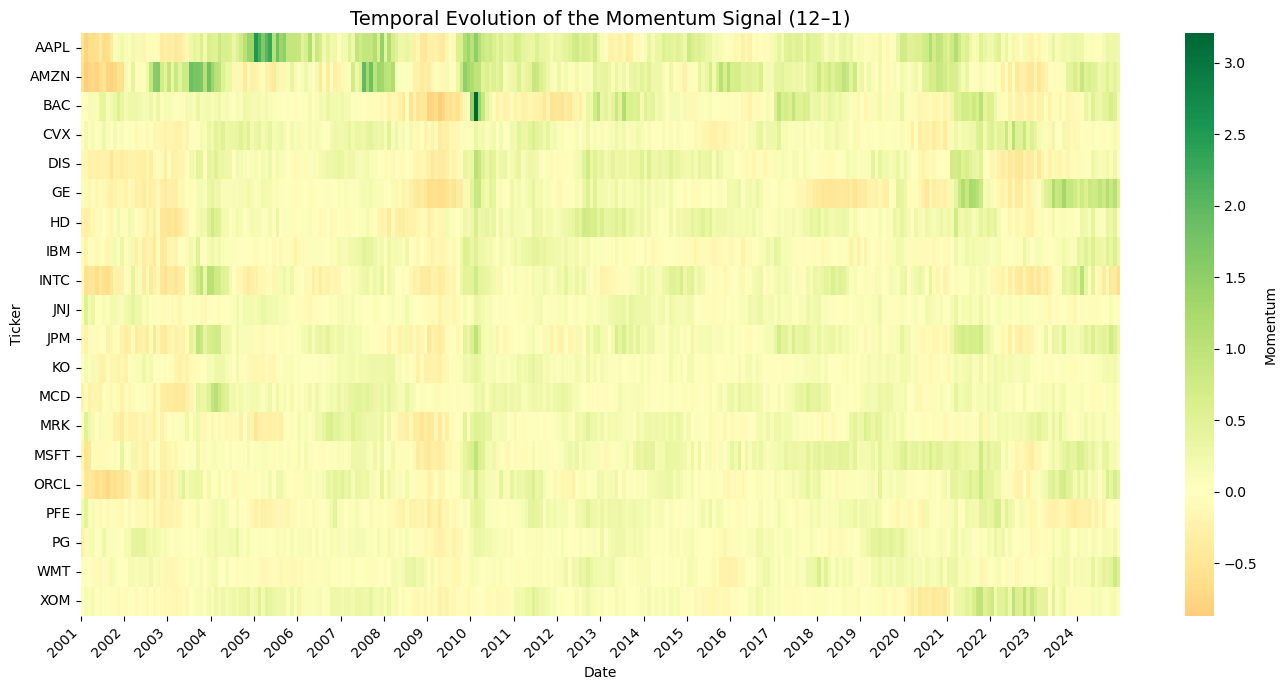

In [6]:
plt.figure(figsize=(14, 7))
ax = sns.heatmap(cross_sectional_alpha_signal.T, cmap="RdYlGn", center=0, cbar_kws={"label": "Momentum"})

plt.title("Temporal Evolution of the Momentum Signal (12–1)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Ticker")

n = len(cross_sectional_alpha_signal.index)
step = 12  # one label every 12 months (≈ yearly)
tick_positions = range(0, n, step)
tick_labels = cross_sectional_alpha_signal.index[tick_positions].strftime("%Y")

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Darker shades indicate higher positive relative strength
# Lighter shades indicate severe negative divergence

## 4. Cross-Sectional Ranking
Every month the universe is sorted by its momentum score.  
- **Top quintile (Winners):** stocks with the strongest trailing performance  
- **Bottom quintile (Losers):** stocks with the weakest trailing performance  

These ranks drive which names enter the long and short legs of the portfolio.


In [7]:
ranks = cross_sectional_alpha_signal.rank(axis=1, ascending=False, method='first')
n_assets = cross_sectional_alpha_signal.shape[1]
cut = int(n_assets * alpha_quantile_threshold)

winners_mask = (ranks <= cut).astype(int)
losers_mask = (ranks >= n_assets - cut + 1).astype(int)

## 5. Portfolio Weight Assignment
Within each leg we apply **equal weighting**:
- **Long-only portfolio:** uniform allocation across winners only  
- **Long-short portfolio:** uniform long in winners, uniform short in losers (dollar-neutral)  

Weights are re-normalised at every rebalance date to maintain balance.


In [8]:
Nw = winners_mask.sum(axis=1)
Nl = losers_mask.sum(axis=1)

target_weights_long_only = winners_mask.div(Nw, axis=0)
target_weights_market_neutral = winners_mask.div(Nw, axis=0) - losers_mask.div(Nl, axis=0)

## 6. Overlapping Cohort Holding (H = 3)
Rather than rebalancing the entire book monthly, we layer three staggered monthly cohorts.  
The effective allocation at time *t* averages the last three cohort vectors:

$$
w_t \;=\; \frac{1}{H}\sum_{h=0}^{H-1} w_{t-h}
$$

This overlap dampens turnover and smooths the return stream.


In [9]:
# Implement staggered 3-month portfolio holdings
target_weights_overlapping = sum([target_weights_market_neutral.shift(i) for i in range(holding_period_months)]) / holding_period_months
target_weights_overlapping = target_weights_overlapping.dropna()

## 7. Selection Frequency
The bar chart counts how often each ticker landed in the winner or loser bucket over the full sample.  
A large positive net count (Winners – Losers) highlights names with sustained relative strength.


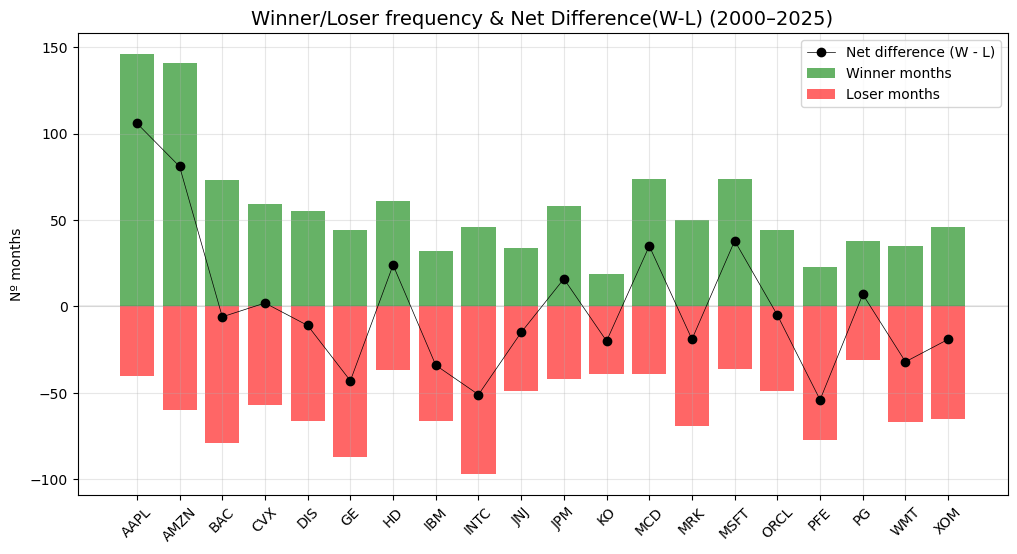

In [10]:
winners_freq = winners_mask.sum(axis=0)
losers_freq = losers_mask.sum(axis=0)

diff_freq = winners_freq - losers_freq

plt.figure(figsize=(12,6))

plt.bar(winners_freq.index, winners_freq, color="green", alpha=0.6, label="Winner months")
plt.bar(losers_freq.index, -losers_freq, color="red", alpha=0.6, label="Loser months")

plt.plot(diff_freq.index, diff_freq, color="black", linewidth=0.5, marker="o", label="Net difference (W - L)")

plt.axhline(0, color="black", linewidth=0.1)
plt.xticks(rotation=45)
plt.title("Winner/Loser frequency & Net Difference(W-L) (2000–2025)", fontsize=14)
plt.ylabel("Nº months")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Portfolio Exposure Through Time
This line chart tracks the aggregate net exposure (sum of weights) of each portfolio variant.  
The long-short book should hover near zero, confirming approximate market neutrality, while the long-only book stays fully invested.


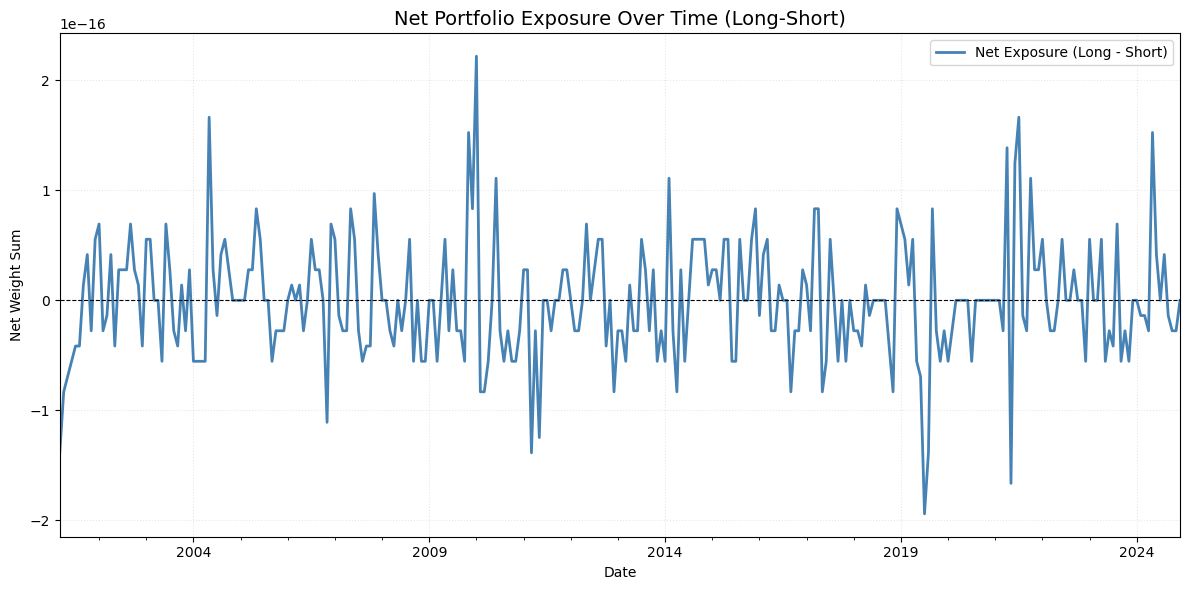

In [11]:
plt.figure(figsize=(12, 6))
target_weights_overlapping.sum(axis=1).plot(color='steelblue', lw=2, label='Net Exposure (Long - Short)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Net Portfolio Exposure Over Time (Long-Short)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Net Weight Sum")
plt.grid(alpha=0.3, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
cross_sectional_alpha_signal.to_csv("data/processed/alpha_signal_matrix.csv")
target_weights_long_only.to_csv("data/processed/allocations_long_only.csv")
target_weights_market_neutral.to_csv("data/processed/allocations_market_neutral.csv")
target_weights_overlapping.to_csv("data/processed/allocations_overlapping.csv")

### Recap
- Built a **12-minus-1 momentum signal** from monthly log returns.  
- Sorted equities into winner and loser quintiles each month.  
- Created equal-weighted **long-only** and **long-short** allocation schemes, including a 3-month overlapping variant.  
- Visualised signal dynamics, selection persistence, and exposure profiles.  

All weight matrices and signals are now stored and ready for the **backtesting and performance evaluation** stage.
